# Práctico Deep Learning para Recomendación

Diplomado Machine Learning Aplicado, PUC Chile

**Profesor:** Vicente Domínguez

**Alumno:** `ESCRIBIR TU NOMBRE AQUI`

En esta actividad trabajaremos con un recomendador de ropa basado netamente en las imagenes más similares extrayendo features con redes neuronales convolucionales.



In [ ]:
from keras.applications import vgg16, vgg19, ResNet50
from tensorflow.keras.utils import load_img,img_to_array
from keras.models import Model
from keras.applications.imagenet_utils import preprocess_input

from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

En esta sección se trabajará con modelos pre-entrenados de redes convolucionales (CNN) que extraen caracteristicas visuales de las imagenes.

![Ejemplo de red convolucional](https://www.researchgate.net/publication/326658868/figure/fig3/AS:962202072805390@1606418259908/AlexNet-architecture-This-shows-the-process-to-obtain-the-latent-feature-vector-we-use.png)


Para los curiosos se recomienda revisar los siguientes links:

- Artículo: [Understand Deep Residual Networks](https://medium.com/@14prakash/understanding-and-implementing-architectures-of-resnet-and-resnext-for-state-of-the-art-image-cf51669e1624)
- [Keras applications](https://keras.io/applications/)

# descarga de imagenes

In [ ]:
%%capture
!gdown 1iLOeNZw69iyYXa7QS5ZutN7ACUpkbL3x
!unzip images_fashion.zip
!mkdir images
!mv *.png images/

# cargamos la CNN pre-entrenada en ImageNet


In [ ]:
# cargamos el modelo escoger

modelo_escogido = 'vgg19' #@param["vgg16", "vgg19"]

if modelo_escogido == 'vgg16':
  # cargar modelo
  vgg_model = vgg16.VGG16(weights='imagenet')
  # quitar la capa de clasificacion
  feat_extractor = Model(inputs=vgg_model.input, outputs=vgg_model.get_layer("fc2").output)
  # vemos resumen de la arquitectura del modelo
  feat_extractor.summary()

elif modelo_escogido == 'vgg19':
  # cargar modelo
  vgg19_model = vgg19.VGG19(weights='imagenet')
  # quitar la capa de clasificacion
  feat_extractor = Model(inputs=vgg19_model.input, outputs=vgg19_model.get_layer("fc2").output)
  # vemos resumen de la arquitectura del modelo
  feat_extractor.summary()



574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 139,570,240 (532.42 MB)

 Trainable params: 139,570,240 (532.42 MB)

 Non-trainable params: 0 (0.00 B)

## procesamiento de imágenes para dárselas como input a la CNN

In [ ]:
ls

images/  images_fashion.zip  __MACOSX/  sample_data/  style.csv  style.txt


In [ ]:
imgs_path = "images/" # ruta

imgs_model_width, imgs_model_height = 224, 224 # tamaño de las imagenes 224x224 pixeles

nb_closest_images = 5 # cantidad de imagenes similares a recomendar

In [ ]:
files = [imgs_path + x for x in os.listdir(imgs_path) if "png" in x]
print("total de imagenes:",len(files))

total de imagenes: 2184


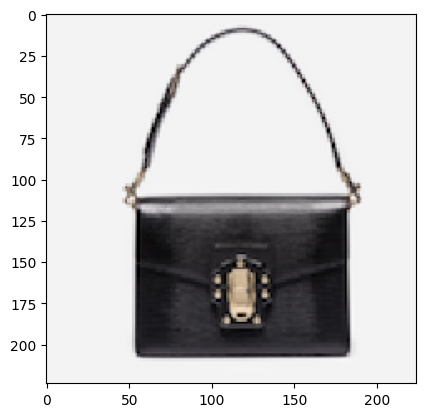

image cargada exitosamente!


In [ ]:
# vemos imagen aleatoria
import random

idx =  random.randint(0, len(files))
original = load_img(files[idx], target_size=(imgs_model_width, imgs_model_height))
plt.imshow(original)
plt.show()
print("image cargada exitosamente!")

In [ ]:
# convertir PIL image a numpy array
numpy_image = img_to_array(original)

# convertir imagen a batch de imagenes para entrenamiento más eficiente
image_batch = np.expand_dims(numpy_image, axis=0)
print('image batch size', image_batch.shape)

# preparamos la imagen para la VGG16
processed_image = preprocess_input(image_batch.copy())

processed_image

image batch size (1, 224, 224, 3)


array([[[[139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         ...,
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ]],

        [[139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         ...,
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ]],

        [[139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         ...,
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ]],

        ...,

        [[139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         ...,
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ],
         [139.061, 126.221, 119.32 ]],

        [[

In [ ]:
# obtenemos los features (embeddings) de las imagenes pasandolas por la VGG16
img_features = feat_extractor.predict(processed_image)

print("features successfully extracted!")
print("number of image features:",img_features.size)
img_features

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
features successfully extracted!
number of image features: 4096


array([[0.       , 0.       , 1.2809867, ..., 0.       , 0.       ,
        2.7483644]], dtype=float32)

In [ ]:
img_features.shape

(1, 4096)

In [ ]:
# repetimos el mismo proceso para todas las imagenes y guardamos los batch en una lista para entregarselos procesados a la VGG16
importedImages = []

for f in files:
    filename = f
    original = load_img(filename, target_size=(224, 224))
    numpy_image = img_to_array(original)
    image_batch = np.expand_dims(numpy_image, axis=0)

    importedImages.append(image_batch)

images = np.vstack(importedImages)

processed_imgs = preprocess_input(images.copy())

In [ ]:
# obtenemos los features para cada imagen con la CNN
imgs_features = feat_extractor.predict(processed_imgs)

print("features extraidos exitosamente!")
imgs_features.shape

69/69 ━━━━━━━━━━━━━━━━━━━━ 29s 259ms/step
features extraidos exitosamente!


(2184, 4096)

In [ ]:
# computa similaridad coseno entre los features de las imagenes
cosSimilarities = cosine_similarity(imgs_features)

# guardamos los resultados en un dataframe
cos_similarities_df = pd.DataFrame(cosSimilarities, columns=files, index=files)
cos_similarities_df #.head()

,images/6_0_020.png,images/4_0_009.png,images/2_2_013.png,images/4_9_040.png,images/3_2_022.png,images/1_4_025.png,images/6_2_039.png,images/1_0_007.png,images/6_8_025.png,images/1_5_018.png,...,images/1_4_026.png,images/5_2_054.png,images/6_1_046.png,images/0_0_089.png,images/5_8_018.png,images/6_3_033.png,images/4_7_027.png,images/4_1_039.png,images/6_3_023.png,images/1_5_035.png
images/6_0_020.png,1.000000,0.246936,0.209608,0.239491,0.305540,0.308186,0.210010,0.224538,0.189205,0.205151,...,0.373160,0.214840,0.270157,0.253586,0.273313,0.284920,0.162541,0.198189,0.303562,0.217129
images/4_0_009.png,0.246936,1.000000,0.142318,0.179492,0.312178,0.207687,0.215470,0.448800,0.380355,0.168215,...,0.306302,0.261723,0.225485,0.599731,0.398111,0.163259,0.254284,0.117209,0.130517,0.204551
images/2_2_013.png,0.209608,0.142318,1.000000,0.201766,0.176499,0.216382,0.448095,0.313943,0.160433,0.211227,...,0.375106,0.341248,0.254628,0.197433,0.235149,0.149915,0.260157,0.360927,0.193518,0.301693
images/4_9_040.png,0.239491,0.179492,0.201766,1.000000,0.350595,0.402809,0.153217,0.223418,0.166511,0.230817,...,0.347270,0.310932,0.271554,0.311761,0.204369,0.214162,0.542297,0.246902,0.238317,0.260798
images/3_2_022.png,0.305540,0.312178,0.176499,0.350595,1.000000,0.318539,0.264678,0.323799,0.242528,0.328042,...,0.297141,0.427324,0.365936,0.344738,0.308130,0.227647,0.359357,0.250167,0.286796,0.236010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
images/6_3_033.png,0.284920,0.163259,0.149915,0.214162,0.227647,0.223811,0.163699,0.114115,0.135153,0.404914,...,0.217456,0.206086,0.271695,0.129416,0.176450,1.000000,0.167395,0.285303,0.312038,0.246901
images/4_7_027.png,0.162541,0.254284,0.260157,0.542297,0.359357,0.277576,0.210781,0.304077,0.172276,0.231351,...,0.320384,0.291357,0.288884,0.383439,0.182183,0.167395,1.000000,0.269195,0.172507,0.299226
images/4_1_039.png,0.198189,0.117209,0.360927,0.246902,0.250167,0.194951,0.215338,0.186776,0.180975,0.323944,...,0.265778,0.255136,0.536756,0.178648,0.145384,0.285303,0.269195,1.000000,0.343026,0.203139
images/6_3_023.png,0.303562,0.130517,0.193518,0.238317,0.286796,0.207849,0.218670,0.214821,0.237856,0.345586,...,0.309213,0.263883,0.457584,0.219533,0.197456,0.312038,0.172507,0.343026,1.000000,0.313158


In [ ]:
# esta funcion recupera las imagenes más similares dada una imagen entregada por el usuario
def retrieve_most_similar_products(given_img):

    print("-----------------------------------------------------------------------")
    print("producto escogido:")

    original = load_img(given_img, target_size=(imgs_model_width, imgs_model_height))
    plt.imshow(original)
    plt.show()

    print("-----------------------------------------------------------------------")
    print("productos más similares:")

    closest_imgs = cos_similarities_df[given_img].sort_values(ascending=False)[1:nb_closest_images+1].index
    closest_imgs_scores = cos_similarities_df[given_img].sort_values(ascending=False)[1:nb_closest_images+1]

    for i in range(0,len(closest_imgs)):
        original = load_img(closest_imgs[i], target_size=(imgs_model_width, imgs_model_height))
        plt.imshow(original)
        plt.show()
        print("score de similaridad : ",closest_imgs_scores[i])

1100
images/4_2_024.png
-----------------------------------------------------------------------
producto escogido:


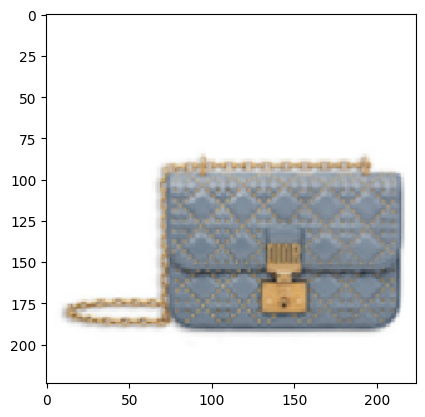

-----------------------------------------------------------------------
productos más similares:


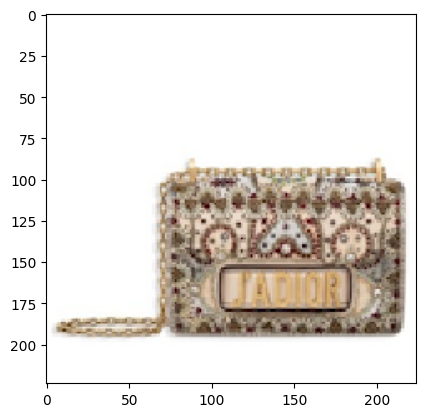

score de similaridad :  0.7719287


/tmp/ipython-input-1698311365.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("score de similaridad : ",closest_imgs_scores[i])


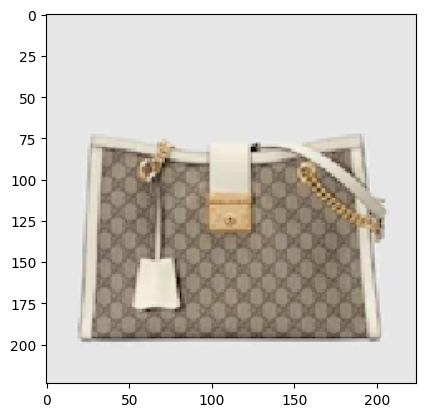

score de similaridad :  0.7548596


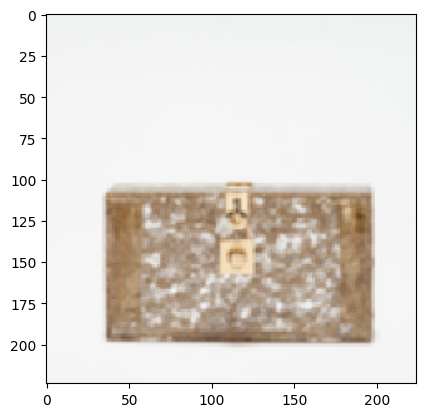

score de similaridad :  0.75094175


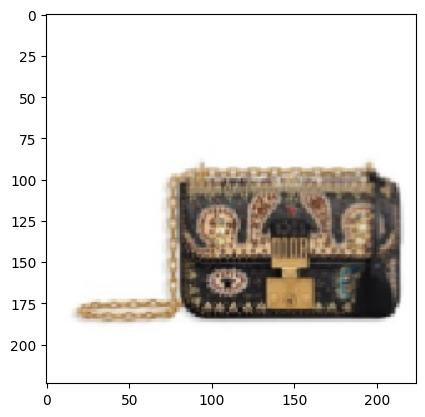

score de similaridad :  0.73812383


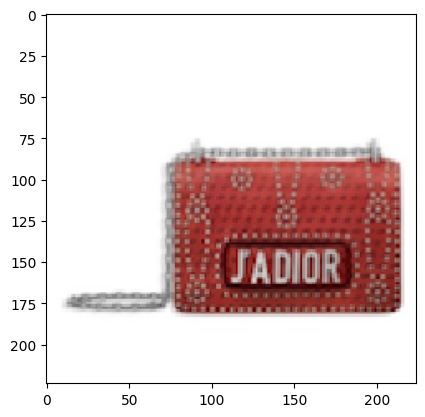

score de similaridad :  0.73706794


In [ ]:
idx = 1100 # random.randint(0, len(files))
random.randint(0, len(files))
print(idx)
print(files[idx])
retrieve_most_similar_products(files[idx])

# ACTIVIDAD

1. Mostrar 2 ejemplos de búsqueda de imagenes similares utilizando ambas arquitecturas (VGG16 y VGG19) e imprimir los resultados. (3 ptos)

2. ¿Cuál de las dos arquitecturas (VGG16 o VGG19) tiene más parámetros entrenables después de quitar la última capa de clasificación?. Justifique indicando la cantidad de parámetros de cada una. (2 ptos)


Pregunta 1:

VGG 16

In [ ]:
# busqueda 1

In [ ]:
# busqueda 2

VGG 19

In [ ]:
# busqueda 1

In [ ]:
# busqueda 2

Pregunta 2
- parametros entrenables VGG16 sin ultima capa
- parametros entrenables VGG19 sin ultima capa


